# NYC Property Data Cleaning & Enrichment Pipeline
This notebook implements a robust, auditable workflow for cleaning, merging, and enriching New York City property data. The pipeline ensures data integrity, provenance, and consistency through the following stages:
- **Configuration & Logging:** Centralized setup for file paths, deduplication keys, and logging utilities.
- **Data Loading & Inspection:** Loads raw property and geocode datasets, with initial inspection and missing value checks.
- **Standardization & Cleaning:** Normalizes addresses, extracts and reconciles ZIPCODEs, adjusts property types, and preserves original address for provenance.
- **Merging & Deduplication:** Merges property data with geocode info, then deduplicates using a composite key (house/unit/coordinates) to ensure true uniqueness.
- **Enrichment:** Fills missing SUBLOCALITY and BOROUGH fields using comprehensive ZIPCODE mappings, and applies targeted fixes for known issues.
- **Validation & Visualization:** Provides summary statistics, missing value checks, and a geo scatter plot for visual validation.
- **Export:** Saves the cleaned DataFrame to CSV, ensuring the output directory exists to prevent errors.

This workflow is designed for transparency, auditability, and easy extension to new data or requirements.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hashlib, json, os, re
from datetime import datetime as _dt, timezone as _tz
print('Core imports loaded.')

Core imports loaded.


In [2]:
# Step 1.1: Configuration & Logging Setup (split from monolithic cell)
CONFIG = {
    'paths': {
        'raw_main': 'Resources/NY-House-Dataset.csv',
        'raw_geo': 'Resources/housing_geocode_extraction.csv',
        'output_csv': 'output/cleaned_house_dataset.csv',
    },
    'dedupe_primary_subset': ['ADDRESS'],                # primary uniqueness (address only)
    'dedupe_strict_subset': ['ADDRESS','LATITUDE','LONGITUDE'],  # optional stricter pass
    'geo_sample_size': 4000,
    'random_seed': 42,
    'pipeline_version': '1.0.0'
}

STEP_LOG = []

def log_step(name, df, note=''):
    STEP_LOG.append({'step': name, 'rows': len(df), 'note': note})

print('Configuration & STEP_LOG initialized.')


Configuration & STEP_LOG initialized.


In [3]:
# Snapshot Utility (Early Definition)
import hashlib, pandas as _pd
CHANGE_LOG = [] if 'CHANGE_LOG' not in globals() else CHANGE_LOG

def snapshot(stage: str, df: _pd.DataFrame, sample_rows: int = 5):
    """Record structural + small sample preview for before/after auditing."""
    meta = {
        'stage': stage,
        'row_count': int(df.shape[0]),
        'col_count': int(df.shape[1]),
        'columns': list(df.columns)
    }
    subset = df.iloc[:1000, :20]
    meta['sample_hash'] = hashlib.md5(subset.to_csv(index=False).encode('utf-8')).hexdigest()
    meta['sample_preview'] = subset.head(sample_rows).to_dict(orient='records')
    CHANGE_LOG.append(meta)
    return meta
print('Early snapshot utility ready.')

Early snapshot utility ready.


## Stage 1: Data Loading & Initial Inspection
Load the raw property and geocode datasets, and perform initial inspection for structure and missing values.

In [4]:
#: Load Raw Datasets (with snapshot)
import pandas as pd
main_path = CONFIG['paths']['raw_main']
geo_path = CONFIG['paths']['raw_geo']
print(f"Loading raw files:\n  main -> {main_path}\n  geo  -> {geo_path}")
raw_df = pd.read_csv(main_path)
geo_df = pd.read_csv(geo_path)
print(f"Raw shapes: main={raw_df.shape}, geo={geo_df.shape}")
# snapshot raw
# snapshot('raw_loaded_main', raw_df)


Loading raw files:
  main -> Resources/NY-House-Dataset.csv
  geo  -> Resources/housing_geocode_extraction.csv


Raw shapes: main=(4801, 17), geo=(4801, 8)


In [5]:
# Inspect raw_df and geo_df after loading
print("=== raw_df preview ===")
display(raw_df.head(5))
print("\nraw_df info:")
raw_df.info()
print("\nMissing values in raw_df:")
print(raw_df.isna().sum())

print("\n=== geo_df preview ===")
display(geo_df.head(5))
print("\ngeo_df info:")
geo_df.info()
print("\nMissing values in geo_df:")
print(geo_df.isna().sum())

=== raw_df preview ===


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856



raw_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG

,LATITUDE,LONGITUDE,STATE,LOCALITY,SUBLOCALITY,POSTCODE,PROPERTY_CATEGORY,GEOCODING_TYPE
0,40.761255,-73.974483,New York,New York,Midtown East,10022,amenity,amenity
1,40.766393,-73.980991,New York,New York,NaN,10019,amenity,amenity
2,40.541805,-74.196109,New York,New York,NaN,10312,building,building
3,40.761398,-73.974613,New York,New York,Midtown East,10022,amenity,amenity
4,40.767224,-73.969856,New York,New York,NaN,10065,building,building



geo_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LATITUDE           4801 non-null   float64
 1   LONGITUDE          4801 non-null   float64
 2   STATE              4800 non-null   object 
 3   LOCALITY           4800 non-null   object 
 4   SUBLOCALITY        1923 non-null   object 
 5   POSTCODE           4800 non-null   object 
 6   PROPERTY_CATEGORY  4800 non-null   object 
 7   GEOCODING_TYPE     4800 non-null   object 
dtypes: float64(2), object(6)
memory usage: 300.2+ KB

Missing values in geo_df:
LATITUDE                0
LONGITUDE               0
STATE                   1
LOCALITY                1
SUBLOCALITY          2878
POSTCODE                1
PROPERTY_CATEGORY       1
GEOCODING_TYPE          1
dtype: int64


In [6]:
# Check and compare the columns in both dataframes to understand structure and alignment
print('Columns in geocode extraction:', geo_df.columns.tolist())
print('Columns in NY-House-Dataset:', raw_df.columns.tolist())

Columns in geocode extraction: ['LATITUDE', 'LONGITUDE', 'STATE', 'LOCALITY', 'SUBLOCALITY', 'POSTCODE', 'PROPERTY_CATEGORY', 'GEOCODING_TYPE']
Columns in NY-House-Dataset: ['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE']


## Stage 2: Standardization & Cleaning
Normalize addresses, extract and reconcile ZIPCODEs, adjust property types, and preserve the original address for provenance.

In [7]:
def _normalize_broker_type(df: pd.DataFrame) -> pd.DataFrame:
    if 'BROKERTITLE' in df.columns:
        df['BROKERTITLE'] = (df['BROKERTITLE']
                              .str.replace('Brokered by ', '', regex=False)
                              .str.split(r'\s*[-|–]\s*').str[0]
                              .str.strip()
                              .str.title())
        log_step('broker_clean', df, 'Broker title normalized')
    if 'TYPE' in df.columns:
        df['TYPE'] = df['TYPE'].str.replace(' for sale', '', regex=False)
        log_step('type_trim_phrase', df)
    return df

def _consolidate_address(df: pd.DataFrame) -> pd.DataFrame:
    if 'FORMATTED_ADDRESS' in df.columns:
        df['ADDRESS'] = df['FORMATTED_ADDRESS']
        drop_cols = ['MAIN_ADDRESS', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS']
        df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
        log_step('address_consolidate', df)
    return df

def _extract_zip_from_state(df: pd.DataFrame) -> pd.DataFrame:
    if 'STATE' in df.columns:
        df['ZIPCODE'] = df['STATE'].str.extract(r'(\d{5})')
        df.drop(columns=['STATE'], inplace=True)
        log_step('zip_from_state', df)
    return df

def _drop_locality(df: pd.DataFrame) -> pd.DataFrame:
    for col in ['LOCALITY', 'ADMINISTRATIVE_AREA_LEVEL_2']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    log_step('drop_locality_cols', df)
    return df

In [8]:
def clean_numeric_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert numeric columns to proper dtype and clean invalid values.
    
    - Converts PRICE, BEDS, BATH, PROPERTYSQFT to numeric.
    - Drops rows where BATH == 0 (land, not house) BEFORE rounding.
    - Rounds BATH and PROPERTYSQFT to 2 decimal places (after dropping land rows).
    """
    numeric_cols = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']
    
    # --- Step 1: Convert to numeric ---
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # --- Step 2: Remove land rows (BATH == 0) BEFORE rounding ---
    if 'BATH' in df.columns:
        pre_drop = len(df)
        land_mask = df['BATH'] == 0
        dropped_land = df[land_mask]
        df = df[~land_mask].copy()
        post_drop = len(df)
        print(f"Dropped {pre_drop - post_drop} rows with BATH == 0 (land, not house)")
        if not dropped_land.empty:
            print("Sample dropped rows:")
            display(dropped_land.head(5))
    
    # --- Step 3: Round decimals (after dropping land rows) ---
    if 'BATH' in df.columns:
        df['BATH'] = df['BATH'].round(2)
    if 'PROPERTYSQFT' in df.columns:
        df['PROPERTYSQFT'] = df['PROPERTYSQFT'].round(2)
    
    return df

In [9]:

raw_df = clean_numeric_columns(raw_df)
raw_df = _normalize_broker_type(raw_df)
raw_df = _consolidate_address(raw_df)
raw_df = _extract_zip_from_state(raw_df)
raw_df = _drop_locality(raw_df)
# preview
raw_df.tail(3)

Dropped 3 rows with BATH == 0 (land, not house)
Sample dropped rows:


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
2699,Brokered by COMPASS,Pending,675000,3,0.0,2780.000000,41 Warren St Unit Subc,"Manhattan, NY 10007","41 Warren St Unit SubcManhattan, NY 10007",New York,New York County,New York,Manhattan,41,"41 Warren St b, New York, NY 10007, USA",40.714393,-74.008877
2704,Brokered by COMPASS,Pending,675000,3,0.0,2780.000000,41 Warren St Unit Subc,"Manhattan, NY 10007","41 Warren St Unit SubcManhattan, NY 10007",New York,New York County,New York,Manhattan,41,"41 Warren St b, New York, NY 10007, USA",40.714393,-74.008877
3379,Brokered by Brown Harris Stevens,Townhouse for sale,14995000,3,0.0,2184.207862,50 W 86th St Unit Townhouse,"Manhattan, NY 10024","50 W 86th St Unit TownhouseManhattan, NY 10024",United States,New York,New York County,New York,West 86th Street,"50 W 86th St, New York, NY 10024, USA",40.786046,-73.971834


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,SUBLOCALITY,LATITUDE,LONGITUDE,ZIPCODE
4798,Douglas Elliman,Co-op,1275000,1,1.0,2184.21,"427 W 21st St, New York, NY 10011, USA",New York County,40.745882,-74.003398,10011
4799,E Realty International Corp,Condo,598125,2,1.0,655.00,"91-23 Corona Ave. #4b, Flushing, NY 11373, USA",Queens,40.742770,-73.872752,11373
4800,Nyc Realty Brokers Llc,Co-op,349000,1,1.0,750.00,"460 Neptune Ave #14a, Brooklyn, NY 11224, USA",Brooklyn,40.579147,-73.970949,11224


### Cleaning and standardizing the address while reconciling ZIPCODEs and adjusting property TYPEs
This section performs advanced cleaning and normalization of property addresses. Key steps include:
- Preserving the original address for provenance and later extraction of sublocality/borough.
- Extracting ZIPCODEs from both the raw and cleaned address fields, ensuring all ZIPCODEs are valid and NYC-specific.
- Removing extraneous tokens (borough, state, country, sublocality) from addresses for consistency.
- Expanding abbreviations and applying smart title casing for readability.
- Adjusting the property TYPE field based on address keywords and known mappings.
- Providing debug output for missing or invalid ZIPCODEs and a preview of cleaned data.

In [10]:
# Display all unique addresses in raw_df
unique_addresses = raw_df['ADDRESS'].dropna().unique()
print(f"Total unique addresses: {len(unique_addresses)}")
for addr in unique_addresses:
    print(addr)


Total unique addresses: 4548
Regis Residence, 2 E 55th St #803, New York, NY 10022, USA
217 W 57th St, New York, NY 10019, USA
620 Sinclair Ave, Staten Island, NY 10312, USA
2 E 55th St, New York, NY 10022, USA
5 E 64th St, New York, NY 10065, USA
584 Park Pl, Brooklyn, NY 11238, USA
157 W 126th St #1b, New York, NY 10027, USA
177 Benedict Rd, Staten Island, NY 10304, USA
Parking lot, 875 Morrison Ave #3m, Bronx, NY 10473, USA
1350 Ocean Pkwy #5g, Brooklyn, NY 11230, USA
800 Grand Concourse #2j, Bronx, NY 10451, USA
456 Van Name Ave, Staten Island, NY 10303, USA
34-41 85th St #1b, Flushing, NY 11372, USA
91-15 Lamont Ave #6d, Elmhurst, NY 11373, USA
61 Jane St #6n, New York, NY 10014, USA
4654 Amboy Rd #2b, Staten Island, NY 10312, USA
28-31 Hobart St, Flushing, NY 11377, USA
9430 Ridge Blvd #6d, Brooklyn, NY 11209, USA
5800 Arlington Ave Apt 21s, Bronx, NY 10471, USA
92-29 Queens Blvd #3h, Rego Park, NY 11374, USA
27 Clove Way, Staten Island, NY 10301, USA
10724 71st Rd #9f, Forest Hi

In [29]:
# NYC ZIP prefixes for validation
NYC_ZIP_PREFIXES = ('100','101','102','103','104','110','111','112','113','114','116')

ABBREV_MAP = {
    r'\bst\.\b': 'street', r'\bst\b': 'street',
    r'\bave\.\b': 'avenue', r'\bave\b': 'avenue',
    r'\bblvd\.\b': 'boulevard', r'\bblvd\b': 'boulevard',
    r'\brd\.\b': 'road', r'\brd\b': 'road',
    r'\bdr\.\b': 'drive', r'\bdr\b': 'drive',
    r'\bln\.\b': 'lane', r'\bln\b': 'lane',
    r'\bpl\.\b': 'place', r'\bpl\b': 'place',
    r'\bpkwy\.\b': 'parkway', r'\bpkwy\b': 'parkway',
    r'\bpky\.\b': 'parkway', r'\bpky\b': 'parkway'
}

APT_KEYWORDS = (' apt',' apt.',' unit',' unit.',' suite',' ste',' fl ',' #')
HOUSE_KEYWORDS = (' house',' detached')
# --- Step 0: Preserve raw address ---
# Preserve raw address before advanced cleaning for later sublocality/borough extraction
if 'ADDRESS_RAW' not in raw_df.columns:
    raw_df['ADDRESS_RAW'] = raw_df['ADDRESS']
addr_original = raw_df['ADDRESS'].fillna('').astype(str)

# --- Step 1: Extract ZIP from ADDRESS_RAW (for missing/invalid ZIPCODE) ---
zip_pattern = r'(\d{5})(?=\s*$)'
if 'ZIPCODE' not in raw_df.columns:
    raw_df['ZIPCODE'] = ''
zip_from_addr_raw = raw_df['ADDRESS_RAW'].astype(str).str.extract(zip_pattern, expand=False)
missing_zip_mask = raw_df['ZIPCODE'].isna() | ~raw_df['ZIPCODE'].astype(str).str.fullmatch(r'\d{5}')
update_zip_mask = missing_zip_mask & zip_from_addr_raw.notna() & zip_from_addr_raw.astype(str).str.fullmatch(r'\d{5}')
raw_df.loc[update_zip_mask, 'ZIPCODE'] = zip_from_addr_raw[update_zip_mask]

# --- Step 2: Extract ZIP from cleaned address tail (for any still missing) ---
addr_zip = addr_original.str.extract(r'(\d{5})(?=\s*$)', expand=False)
still_missing_zip = raw_df['ZIPCODE'].isna() | ~raw_df['ZIPCODE'].astype(str).str.fullmatch(r'\d{5}')
raw_df.loc[still_missing_zip, 'ZIPCODE'] = addr_zip[still_missing_zip]

# --- Step 3: Reconcile ZIPCODE column (prefer NYC ZIPs from address) ---
raw_df['ZIPCODE'] = raw_df['ZIPCODE'].astype(str).str.extract(r'(\d{5})', expand=False)
raw_df['ZIPCODE'] = raw_df['ZIPCODE'].where(raw_df['ZIPCODE'].str.startswith(NYC_ZIP_PREFIXES))

# --- Step 4: Remove ZIP, state, borough, country, and sublocality tokens from address ---
boroughs = ['new york','nyc','ny','usa','united states','brooklyn','queens','manhattan','bronx','staten island']
sublocalities = [
    'chelsea','lower east side','east village','financial district','tribeca','alphabet city','flatiron district','soho','west village','murray hill','midtown east','garment district',
    "hell's kitchen",'upper east side','upper west side','harlem','east harlem','washington heights','inwood','midtown west','battery park city','roosevelt island',
    'mott haven','fordham','kingsbridge','east bronx','morrisania','claremont village','mount hope','morris heights','hunts point','longwood','belmont','pelham parkway','throggs neck','pelham bay','van nest','baychester','riverdale','co-op city','eastchester','wakefield','clason point','city island',
    'brooklyn heights','flatbush','borough park','williamsburg','east new york','brownsville','crown heights','bath beach','park slope','bed-stuy','bushwick','greenpoint','bensonhurst','coney island','midwood','red hook','sunset park','canarsie','sheepshead bay','dumbo',
    'astoria','long island city','sunnyside','flushing','whitestone','murray hill','fresh meadows','douglaston','bayside','east elmhurst','forest hills','rego park','jackson heights','bellerose','queens village','jamaica','rockaway',
    'st. george','port richmond','stapleton','mariner\'s harbor','new dorp','tottenville','mid-island','south beach','huguenot','elmhurst'
 ]
remove_tokens = boroughs + sublocalities
remove_pattern = r'(,\s*(' + '|'.join([re.escape(t) for t in remove_tokens]) + '))+$'

addr_work = addr_original.str.replace(r'[ ,]*\b\d{5}(?:-\d{4})?\b\s*$', '', regex=True)
addr_work = addr_work.str.replace(remove_pattern, '', regex=True, flags=re.IGNORECASE)
addr_work = addr_work.str.replace(r'[ ,]+$', '', regex=True)

# --- Step 5: Punctuation & spacing cleanup ---
addr_work = (addr_work
             .str.replace(';', ' ', regex=False)
             .str.replace(r',\s*', ', ', regex=True)
             .str.replace(r'\s+', ' ', regex=True)
             .str.strip(' ,'))

# --- Step 6: Lowercase & expand abbreviations ---
addr_lower = addr_work.str.lower()
for pat, repl in ABBREV_MAP.items():
    addr_lower = addr_lower.str.replace(pat, repl, regex=True)

# --- Step 7: Final tidy pre-case ---
addr_clean = addr_lower.str.replace(r'\s+', ' ', regex=True).str.replace(r',\s*,+', ',', regex=True).str.strip(' ,')

# --- Step 8: Smart title casing ---
DIRECTIONALS = {'n','s','e','w','ne','nw','se','sw'}
UNIT_WORDS = {'apt','unit','suite','ste','fl'}
SUFFIX_FORCE = {'street','avenue','boulevard','road','drive','lane','place','parkway'}

def smart_title(address: str) -> str:
    if not address: return address
    parts = address.split(' ')
    out = []
    for p in parts:
        rawp = p
        if rawp.startswith('#'):
            out.append(rawp.upper()); continue
        core = rawp.strip(',')
        low = core.lower()
        if low in DIRECTIONALS:
            token = low.upper()
        elif low in UNIT_WORDS:
            token = low.title()
        elif low in SUFFIX_FORCE:
            token = low.title()
        elif re.fullmatch(r'\d+[a-zA-Z]?(-\d+[a-zA-Z]?)?', rawp):
            token = rawp.upper()
        else:
            token = low.capitalize()
        if rawp.endswith(',') and not token.endswith(','):
            token += ','
        out.append(token)
    titled = ' '.join(out)
    titled = re.sub(r'\s+,', ',', titled)
    titled = re.sub(r',\s*', ', ', titled)
    titled = re.sub(r'\s+', ' ', titled).strip(' ,')
    return titled

raw_df['ADDRESS'] = addr_clean.apply(smart_title)

# --- Step 9: ZIP metrics and debug output ---
zip_valid_mask = raw_df['ZIPCODE'].astype(str).str.fullmatch(r'\d{5}')
valid_zip_count = int(zip_valid_mask.sum())
invalid_zip_count = int(len(raw_df) - valid_zip_count)

print(f"ZIP Valid: {valid_zip_count} | ZIP Invalid/Missing: {invalid_zip_count}")
if invalid_zip_count > 0:
    print('Sample rows with missing/invalid ZIPCODE after cleaning:')
    display(raw_df.loc[~zip_valid_mask, ['ADDRESS_RAW','ADDRESS','ZIPCODE']].head(10))

print('Building names retained inline (no separate column)')

# --- Step 10: Preview cleaned data ---
preview_cols = ['ADDRESS','ZIPCODE','SUBLOCALITY','TYPE']
print(raw_df[preview_cols].head(10))

ZIP Valid: 4798 | ZIP Invalid/Missing: 0
Building names retained inline (no separate column)
                                 ADDRESS ZIPCODE      SUBLOCALITY   TYPE
0  Regis Residence, 2 E 55th Street #803   10022        Manhattan  condo
1                      217 W 57th Street   10019  New York County  house
2                    620 Sinclair Avenue   10312  Richmond County  house
3                        2 E 55th Street   10022  New York County  house
4                        5 E 64th Street   10065  New York County  house
5                         584 Park Place   11238     Kings County  house
6                 157 W 126th Street #1B   10027         New York  condo
7                      177 Benedict Road   10304  Richmond County  house
8   Parking Lot, 875 Morrison Avenue #3M   10473       East Bronx  condo
9                 1350 Ocean Parkway #5G   11230         Brooklyn  condo


### Property TYPE Normalization

To ensure consistency and enable robust analysis, the `TYPE` column is normalized to a canonical set of categories. The mapping consolidates common variants (e.g., 'condominium', 'single family', 'townhome') into standard types (e.g., 'condo', 'house'). Non-property or ambiguous values (e.g., 'pending', 'contingent', 'foreclosure', 'for sale', 'coming soon') are mapped to their own category or to 'other' if not recognized. All unknown or unmapped values are flagged for review below. This step ensures the dataset is ready for downstream modeling and reporting.

In [30]:
# Assign TYPE based only on address: 'condo' (apartment) or 'house'
APT_KEYWORDS = ['#', 'unit', 'apt', 'apartment', 'condo']
def address_to_type(address):
    address = str(address).lower()
    if any(k in address for k in APT_KEYWORDS):
        return 'condo'
    return 'house'
raw_df['TYPE'] = raw_df['ADDRESS'].apply(address_to_type)
print(raw_df['TYPE'].value_counts())

TYPE
house    2594
condo    2204
Name: count, dtype: int64


## Stage 3: Merging & Deduplication
Merge the cleaned property data with geocode information, then deduplicate using a composite key (house/unit/coordinates) to ensure true uniqueness.

In [31]:
# --- Geo Data Cleanup & Merge ---
# 1. Keep only relevant geo_df columns
geo_keep = ['LATITUDE', 'LONGITUDE', 'SUBLOCALITY', 'POSTCODE']
geo_df = geo_df[[c for c in geo_keep if c in geo_df.columns]].copy()

# 2. Rename POSTCODE to ZIPCODE for merge
if 'POSTCODE' in geo_df.columns:
    geo_df.rename(columns={'POSTCODE': 'ZIPCODE'}, inplace=True)

# 3. Merge on LATITUDE and LONGITUDE
merged_df = raw_df.merge(geo_df, on=['LATITUDE', 'LONGITUDE'], how='left', suffixes=('', '_GEO'))

# 4. Compare ZIPCODE and SUBLOCALITY alignment
zip_match = merged_df['ZIPCODE'] == merged_df.get('ZIPCODE_GEO', merged_df['ZIPCODE'])
subloc_match = merged_df['SUBLOCALITY'] == merged_df.get('SUBLOCALITY_GEO', merged_df['SUBLOCALITY'])

# 5. Fill missing or mismatched ZIPCODE/SUBLOCALITY from geo_df
if 'ZIPCODE_GEO' in merged_df.columns:
    merged_df['ZIPCODE'] = merged_df['ZIPCODE'].where(zip_match, merged_df['ZIPCODE_GEO'])
    merged_df.drop(columns=['ZIPCODE_GEO'], inplace=True)

if 'SUBLOCALITY_GEO' in merged_df.columns:
    merged_df['SUBLOCALITY'] = merged_df['SUBLOCALITY'].where(subloc_match, merged_df['SUBLOCALITY_GEO'])
    merged_df.drop(columns=['SUBLOCALITY_GEO'], inplace=True)

# 6. Final prune: keep essential columns only
final_cols = [
    'LATITUDE', 'LONGITUDE','ADDRESS', 'ZIPCODE', 'SUBLOCALITY', 
    'TYPE','BEDS', 'BATH', 'PROPERTYSQFT','PRICE','BROKERTITLE'
]
final_cols = [c for c in final_cols if c in merged_df.columns]
merged_df = merged_df[final_cols].copy()

print('Final merged shape:', merged_df.shape)
display(merged_df.head(4))


Final merged shape: (6404, 11)


,LATITUDE,LONGITUDE,ADDRESS,ZIPCODE,SUBLOCALITY,TYPE,BEDS,BATH,PROPERTYSQFT,PRICE,BROKERTITLE
0,40.761255,-73.974483,"Regis Residence, 2 E 55th Street #803",10022,Midtown East,condo,2,2.0,1400.0,315000,Douglas Elliman
1,40.761255,-73.974483,"Regis Residence, 2 E 55th Street #803",10022,Midtown East,condo,2,2.0,1400.0,315000,Douglas Elliman
2,40.766393,-73.980991,217 W 57th Street,10019,NaN,house,7,10.0,17545.0,195000000,Serhant
3,40.766393,-73.980991,217 W 57th Street,10019,NaN,house,7,10.0,17545.0,195000000,Serhant


### Why Deduplication Should Be Done After Merge

To ensure each property is truly unique, deduplication should be performed after merging raw_df and geo_df. This is because the merge can enrich or update address/unit information, and you want to deduplicate based on the most complete data. The uniqueness key should combine house/unit number and coordinates, so properties sharing the same building but not the same unit are not dropped.

In [32]:
# --- Create Uniqueness Key & Drop True Duplicates ---
lat_col, lon_col = 'LATITUDE', 'LONGITUDE'

# Extract house number
_house_num = merged_df['ADDRESS'].str.extract(r'^(\d+[A-Za-z]?)', expand=False)

# Extract unit token (APT, UNIT, SUITE, STE, FL, #)
_unit_token = merged_df['ADDRESS'].str.extract(
    r'(?:\b(?:apt|unit|suite|ste|fl)\s*#?\s*([A-Za-z0-9-]+))|(?:#\s*([A-Za-z0-9-]+))',
    expand=True
)
_unit = _unit_token[0].fillna(_unit_token[1])

# Construct uniqueness key: house|unit|lat|lon
merged_df['HOUSE_UNIT_LATLON_KEY'] = (
    _house_num.fillna('').str.lower().str.strip() + '|' +
    _unit.fillna('').str.lower().str.strip() + '|' +
    merged_df[lat_col].fillna(-9999).astype(str) + '|' +
    merged_df[lon_col].fillna(-9999).astype(str)
)

# Drop duplicates based on the uniqueness key
pre_dedupe_rows = len(merged_df)
merged_df = merged_df.drop_duplicates(subset=['HOUSE_UNIT_LATLON_KEY'], keep='first').copy()
post_dedupe_rows = len(merged_df)
removed_rows = pre_dedupe_rows - post_dedupe_rows

print(f'True duplicates removed: {removed_rows}')
print('After dedupe shape:', merged_df.shape)
display(merged_df.head(4))


True duplicates removed: 1900
After dedupe shape: (4504, 12)


,LATITUDE,LONGITUDE,ADDRESS,ZIPCODE,SUBLOCALITY,TYPE,BEDS,BATH,PROPERTYSQFT,PRICE,BROKERTITLE,HOUSE_UNIT_LATLON_KEY
0,40.761255,-73.974483,"Regis Residence, 2 E 55th Street #803",10022,Midtown East,condo,2,2.0,1400.0,315000,Douglas Elliman,|803|40.761255|-73.9744834
2,40.766393,-73.980991,217 W 57th Street,10019,NaN,house,7,10.0,17545.0,195000000,Serhant,217||40.7663935|-73.9809909
4,40.541805,-74.196109,620 Sinclair Avenue,10312,NaN,house,4,2.0,2015.0,260000,Sowae Corp,620||40.5418051|-74.1961086
5,40.761398,-73.974613,2 E 55th Street,10022,Midtown East,house,3,1.0,445.0,69000,Compass,2||40.7613979|-73.9746128


In [33]:
print(f"Merged shape: {merged_df.shape} (geo_df: {geo_df.shape}, raw_df: {raw_df.shape})")


Merged shape: (4504, 12) (geo_df: (4801, 3), raw_df: (4798, 12))


## Stage 4: Enrichment, Validation & Export
Enrich the merged dataset by filling missing SUBLOCALITY and BOROUGH fields, apply targeted fixes, validate the results, visualize the data, and export the cleaned DataFrame to CSV.

In [16]:
# --- Investigate ZIPCODEs: Missing vs Assigned SUBLOCALITY ---
# 1. All unique ZIPCODEs in the dataset
all_zipcodes = merged_df['ZIPCODE'].sort_values().unique()
print("All unique ZIPCODEs in the dataset:")
print(all_zipcodes)

# 2. Find rows with missing SUBLOCALITY (NaN or empty string)
missing_subloc_mask = merged_df['SUBLOCALITY'].isna() | (merged_df['SUBLOCALITY'].astype(str).str.strip() == '')
cols_for_missing = ['ADDRESS','ZIPCODE','SUBLOCALITY']
if 'ADDRESS_RAW' in merged_df.columns:
    cols_for_missing = ['ADDRESS_RAW'] + cols_for_missing
missing_subloc_df = merged_df.loc[missing_subloc_mask, cols_for_missing].copy()
print(f"\nRows with missing SUBLOCALITY: {len(missing_subloc_df)}")
display(missing_subloc_df.head(10))

# 3. ZIPCODEs with missing SUBLOCALITY (for reference, not dropping)
missing_zipcodes = missing_subloc_df['ZIPCODE'].dropna().unique()
print(f"\nZIPCODEs with missing SUBLOCALITY ({len(missing_zipcodes)}):")
# print(sorted(missing_zipcodes))

All unique ZIPCODEs in the dataset:
['07093' '10001' '10002' '10003' '10004' '10005' '10006' '10007' '10009'
 '10010' '10011' '10012' '10013' '10013-1548' '10014' '10016' '10017'
 '10018' '10019' '10021' '10022' '10023' '10024' '10025' '10026' '10027'
 '10028' '10029' '10030' '10031' '10032' '10033' '10034' '10035' '10036'
 '10037' '10038' '10039' '10040' '10044' '10065' '10069' '10075' '10107'
 '10128' '10155' '10275' '10280' '10282' '10301' '10302' '10303' '10304'
 '10305' '10306' '10307' '10308' '10309' '10310' '10312' '10314' '10451'
 '10452' '10453' '10454' '10456' '10457' '10458' '10459' '10460' '10461'
 '10462' '10463' '10464' '10465' '10466' '10467' '10468' '10469' '10470'
 '10471' '10472' '10473' '10474' '10475' '11001' '11004' '11005' '11101'
 '11102' '11103' '11104' '11105' '11106' '11109' '11201' '11203' '11204'
 '11205' '11206' '11207' '11208' '11209' '11210' '11211' '11212' '11213'
 '11214' '11215' '11216' '11217' '11218' '11219' '11220' '11221' '11222'
 '11223' '11224' '

,ADDRESS,ZIPCODE,SUBLOCALITY
2,"217 W 57th Street, New York, Ny 10019",10019,NaN
4,"620 Sinclair Avenue, Staten Island, Ny 10312",10312,NaN
8,"5 E 64th Street, New York, Ny 10065",10065,NaN
9,"584 Park Place, Brooklyn, Ny 11238",11238,NaN
11,"177 Benedict Road, Staten Island, Ny 10304",10304,NaN
14,"800 Grand Concourse #2J, Bronx, Ny 10451",10451,NaN
18,"456 Van Name Avenue, Staten Island, Ny 10303",10303,NaN
19,"34-41 85th Street #1B, Flushing, Ny 11372",11372,NaN
24,"4654 Amboy Road #2B, Staten Island, Ny 10312",10312,NaN
25,"28-31 Hobart Street, Flushing, Ny 11377",11377,NaN



ZIPCODEs with missing SUBLOCALITY (168):


In [17]:
# 4. ZIPCODEs with assigned SUBLOCALITY
assigned_subloc_mask = ~missing_subloc_mask
assigned_zipcodes = merged_df.loc[assigned_subloc_mask, 'ZIPCODE'].dropna().unique()
print(f"\nZIPCODEs with assigned SUBLOCALITY ({len(assigned_zipcodes)}):")
print(sorted(assigned_zipcodes))

# 5. For each ZIPCODE, show the assigned SUBLOCALITY values (for normalization)
print("\nAssigned SUBLOCALITYs per ZIPCODE (sample):")
zip_subloc_map = merged_df.loc[assigned_subloc_mask, ['ZIPCODE', 'SUBLOCALITY']].dropna()
zip_subloc_grouped = zip_subloc_map.groupby('ZIPCODE')['SUBLOCALITY'].unique().reset_index()
# print(zip_subloc_grouped.head(20))
#  6. Optionally, preview rows for manual inspection
print("\nSample rows with assigned SUBLOCALITY:")
display(merged_df.loc[assigned_subloc_mask, ['ADDRESS', 'ZIPCODE', 'SUBLOCALITY']].head(10))
# Display all ZIPCODEs with assigned SUBLOCALITYs (show all 160, not truncated)
pd.set_option('display.max_rows', 200)  # Show up to 200 rows in output
# display(zip_sub_grouped)
# pd.reset_option('display.max_rows')


ZIPCODEs with assigned SUBLOCALITY (160):
['07093', '10001', '10002', '10003', '10004', '10005', '10007', '10009', '10010', '10011', '10012', '10013', '10013-1548', '10014', '10016', '10017', '10018', '10019', '10021', '10022', '10023', '10024', '10025', '10026', '10027', '10028', '10029', '10030', '10031', '10032', '10033', '10034', '10035', '10038', '10040', '10044', '10065', '10069', '10075', '10128', '10280', '10282', '10301', '10302', '10303', '10304', '10305', '10306', '10307', '10308', '10309', '10310', '10312', '10314', '10451', '10452', '10456', '10457', '10458', '10459', '10460', '10461', '10462', '10463', '10464', '10465', '10466', '10467', '10468', '10469', '10470', '10471', '10473', '11001', '11004', '11005', '11101', '11102', '11103', '11104', '11105', '11106', '11201', '11203', '11204', '11205', '11206', '11207', '11208', '11209', '11210', '11211', '11213', '11214', '11215', '11216', '11217', '11218', '11219', '11220', '11221', '11222', '11223', '11224', '11225', '11226

,ADDRESS,ZIPCODE,SUBLOCALITY
0,"Regis Residence, 2 E 55th Street #803, New Yor...",10022,Midtown East
5,"2 E 55th Street, New York, Ny 10022",10022,Midtown East
10,"157 W 126th Street #1B, New York, Ny 10027",10027,Harlem
12,"Parking Lot, 875 Morrison Avenue #3M, Bronx, N...",10473,Soundview Bruckner
13,"1350 Ocean Parkway #5G, Brooklyn, Ny 11230",11230,Midwood
22,"91-15 Lamont Avenue #6D, Elmhurst, Ny 11373",11373,Elmhurst
23,"61 Jane Street #6N, New York, Ny 10014",10014,West Village
26,"9430 Ridge Boulevard #6D, Brooklyn, Ny 11209",11209,Fort Hamilton
29,"92-29 Queens Boulevard #3H, Rego Park, Ny 11374",11374,Elmhurst
33,"1038 Throgs Neck Expy, Bronx, Ny 10465",10465,Throgs Neck


In [18]:
# --- Step: Group addresses by ZIP to inspect sublocality needs ---

# Group addresses under each ZIP
zip_address_groups = (
    merged_df.groupby("ZIPCODE")["ADDRESS"]
    .apply(list)
    .reset_index(name="ADDRESSES")
)

print(f"Total ZIPs: {len(zip_address_groups)}")
display(zip_address_groups.head())  # show first 10 ZIPs for inspection


Total ZIPs: 183


,ZIPCODE,ADDRESSES
0,07093,"[6535 Broadway #1G, Bronx, Ny 10471, 6535 Broa..."
1,10001,"[11 W 30th Street #11F, New York, Ny 10001, 15..."
2,10002,"[150 Rivington Street #3G, New York, Ny 10002,..."
3,10003,"[445 Lafayette Street #14A, New York, Ny 10003..."
4,10004,"[70 Little W Street #26B, New York, Ny 10004, ..."


In [19]:
# # --- Check and fix ZIPCODE and SUBLOCALITY for '797 Fairmount Place' ---
# target_address = '797 Fairmount Place'
# row_mask = merged_df['ADDRESS'].str.contains(target_address, case=False, na=False)
# print(f"Before fix for '{target_address}':")
# display(merged_df.loc[row_mask, ['ADDRESS', 'ZIPCODE', 'SUBLOCALITY']])

# # If missing, extract ZIPCODE from ADDRESS_RAW or ADDRESS
# if 'ADDRESS_RAW' in merged_df.columns:
#     zip_extracted = merged_df.loc[row_mask, 'ADDRESS_RAW'].str.extract(r'(\d{5})(?!\d)', expand=False)
# else:
#     zip_extracted = merged_df.loc[row_mask, 'ADDRESS'].str.extract(r'(\d{5})(?!\d)', expand=False)

# if merged_df.loc[row_mask, 'ZIPCODE'].isna().any() or (merged_df.loc[row_mask, 'ZIPCODE'].astype(str).str.strip() == '').any():
#     merged_df.loc[row_mask, 'ZIPCODE'] = zip_extracted

# # Fill SUBLOCALITY if ZIPCODE is now available and in mapping
# if 'zip_to_subloc_compact' in globals():
#     merged_df.loc[row_mask, 'SUBLOCALITY'] = merged_df.loc[row_mask, 'ZIPCODE'].map(zip_to_subloc_compact)

# print(f"After fix for '{target_address}':")
# display(merged_df.loc[row_mask, ['ADDRESS', 'ZIPCODE', 'SUBLOCALITY']])

In [34]:

# --- Step 1: Ensure ZIPCODE is string and standardized ---
merged_df['ZIPCODE'] = merged_df['ZIPCODE'].astype(str).str.zfill(5)

# --- Step 2: Define ZIPCODE → SUBLOCALITY mapping ---
zip_groups = {
    # Manhattan neighborhoods
    ('10001','10011'): 'Chelsea',
    ('10002',): 'Lower East Side',
    ('10003',): 'East Village',
    ('10004','10005','10006','10038','10275'): 'Financial District',
    ('10007','10013'): 'Tribeca',
    ('10009',): 'Alphabet City',
    ('10010',): 'Flatiron District',
    ('10012',): 'Soho',
    ('10014',): 'West Village',
    ('10016',): 'Murray Hill',
    ('10017','10022'): 'Midtown East',
    ('10018',): 'Garment District',
    ('10019','10036','10069','10107','10155'): "Midtown West / Hell's Kitchen",
    ('10021','10028','10065','10075','10128'): 'Upper East Side',
    ('10023','10024','10025'): 'Upper West Side',
    ('10026','10027','10030','10031','10037','10039'): 'Harlem',
    ('10029','10035'): 'East Harlem',
    ('10032','10033'): 'Washington Heights',
    ('10034','10040'): 'Inwood',
    ('10280','10282'): 'Battery Park City',
    ('10044',): 'Roosevelt Island',

    # Bronx neighborhoods
    ('10451','10452'): 'Mott Haven',
    ('10453',): 'Morrisania',
    ('10454',): 'Claremont Village',
    ('10456',): 'Mount Hope',
    ('10457',): 'Fordham',
    ('10458',): 'Morris Heights',
    ('10459',): 'Hunts Point',
    ('10460',): 'Longwood',
    ('10461',): 'Belmont',
    ('10462',): 'Pelham Parkway',
    ('10463','10468'): 'Kingsbridge',
    ('10464',): 'Throggs Neck',
    ('10465',): 'Pelham Bay',
    ('10466',): 'Van Nest',
    ('10467',): 'Baychester',
    ('10469',): 'Riverdale',
    ('10470',): 'Co-op City',
    ('10471',): 'Eastchester',
    ('10472',): 'Wakefield',
    ('10473',): 'East Bronx',
    ('10474',): 'Clason Point',
    ('10475',): 'City Island',

    # Brooklyn neighborhoods
    ('11201',): 'Brooklyn Heights',
    ('11203','11210','11225','11226'): 'Flatbush',
    ('11204','11218'): 'Borough Park',
    ('11205','11206'): 'Williamsburg',
    ('11207','11208'): 'East New York',
    ('11212',): 'Brownsville',
    ('11213',): 'Crown Heights',
    ('11214',): 'Bath Beach',
    ('11215','11217','11238'): 'Park Slope',
    ('11216','11233',): 'Bed-Stuy',
    ('11221',): 'Bushwick',
    ('11222',): 'Greenpoint',
    ('11223','11228'): 'Bensonhurst',
    ('11224',): 'Coney Island',
    ('11230',): 'Midwood',
    ('11231',): 'Red Hook',
    ('11232',): 'Sunset Park',
    ('11234','11236'): 'Canarsie',
    ('11235',): 'Sheepshead Bay',
    ('11251',): 'DUMBO',

    # Queens neighborhoods
    ('11101','11105','11106','11109'): 'Astoria',
    ('11103',): 'Long Island City',
    ('11104',): 'Sunnyside',
    ('11354','11355','11356','11377','11378','11379'): 'Flushing',
    ('11357','11358'): 'Whitestone',
    ('11360',): 'Murray Hill',
    ('11361','11362','11375'): 'Fresh Meadows',
    ('11363',): 'Douglaston',
    ('11365','11366','11370'): 'Bayside',
    ('11367','11368'): 'Sunnyside',
    ('11369',): 'East Elmhurst',
    ('11372',): 'Forest Hills',
    ('11373','11374'): 'Rego Park',
    ('11385',): 'Jackson Heights',
    ('11001','11004'): 'Bellerose',
    ('11428',): 'Queens Village',
    ('11411','11412','11413','11414','11415','11416','11417','11418','11419',
     '11420','11421','11422','11423','11426','11427','11429','11432','11433',
     '11435','11436'): 'Jamaica',
    ('11691','11692','11693','11694','11697'): 'Rockaway',

    # Staten Island neighborhoods
    ('10301',): 'St. George',
    ('10302',): 'Port Richmond',
    ('10303',): 'Stapleton',
    ('10304',): "Mariner's Harbor",
    ('10305',): 'Port Richmond',
    ('10306',): 'New Dorp',
    ('10307',): 'Tottenville',
    ('10308',): 'St. George',
    ('10309',): 'Mid-Island',
    ('10310',): 'South Beach',
    ('10312',): 'Huguenot',
    ('10314',): 'Tottenville',
}


# --- Step 3: Flatten to dict ZIPCODE → SUBLOCALITY ---
zip_to_subloc_compact = {}
for zips, subloc in zip_groups.items():
    for z in zips:
        zip_to_subloc_compact[z] = subloc

# --- Step 4: Fill missing SUBLOCALITY based on ZIPCODE mapping ---
merged_df['SUBLOCALITY'] = merged_df['SUBLOCALITY'].fillna('')  # replace NaN with empty string
mask_missing = merged_df['SUBLOCALITY'].str.strip() == ''
merged_df.loc[mask_missing, 'SUBLOCALITY'] = merged_df.loc[mask_missing, 'ZIPCODE'].map(zip_to_subloc_compact)

print("Missing SUBLOCALITY after mapping:", merged_df['SUBLOCALITY'].isna().sum())


Missing SUBLOCALITY after mapping: 0


In [21]:
# --- Re-extract and fill missing ZIPCODEs from ADDRESS_RAW or ADDRESS ---
def extract_zip_from_text(text):
    if pd.isna(text): return None
    match = re.search(r'(\d{5})(?!\d)', str(text))
    return match.group(1) if match else None

# Find rows with missing or invalid ZIPCODE
zip_invalid_mask = merged_df['ZIPCODE'].isna() | ~merged_df['ZIPCODE'].astype(str).str.fullmatch(r'\d{5}')

# Try to extract from ADDRESS_RAW if available, else from ADDRESS
if 'ADDRESS_RAW' in merged_df.columns:
    extracted_zip = merged_df.loc[zip_invalid_mask, 'ADDRESS_RAW'].apply(extract_zip_from_text)
else:
    extracted_zip = merged_df.loc[zip_invalid_mask, 'ADDRESS'].apply(extract_zip_from_text)

# Fill ZIPCODE where possible
merged_df.loc[zip_invalid_mask, 'ZIPCODE'] = merged_df.loc[zip_invalid_mask, 'ZIPCODE'].combine_first(extracted_zip)

# Check if any ZIPCODEs are still missing
still_missing = merged_df['ZIPCODE'].isna().sum()
print(f"ZIPCODEs still missing after re-extraction: {still_missing}")
if still_missing > 0:
    display(merged_df.loc[merged_df['ZIPCODE'].isna(), ['ADDRESS','ZIPCODE','SUBLOCALITY']].head(10))

ZIPCODEs still missing after re-extraction: 0


In [35]:
merged_df[['ZIPCODE']].isna().sum()

ZIPCODE    0
dtype: int64

In [69]:
# --- Step 4 : Create BOROUGH mapping based on ZIPCODEs ---
zip_to_borough = {
    # Manhattan
    **{z:'Manhattan' for z in [
        '10001','10002','10003','10004','10005','10006','10007','10009','10010','10011','10012','10013','10014','10016','10017','10018','10019','10021','10022','10023','10024','10025','10026','10027','10028','10029','10030','10031','10032','10033','10034','10035','10036','10037','10038','10039','10040','10044','10065','10069','10075','10128']},
    # Bronx
    **{z:'Bronx' for z in [
        '10451','10452','10453','10454','10456','10457','10458','10459','10460','10461','10462','10463','10464','10465','10466','10467','10468','10469','10470','10471','10472','10473','10474','10475']},
    # Brooklyn
    **{z:'Brooklyn' for z in [
        '11201','11203','11204','11205','11207','11208','11210','11212','11213','11214','11215','11216','11217','11218','11221','11222','11223','11224','11225','11226','11228','11230','11231','11232','11233','11234','11235','11236','11238']},
    # Queens
    **{z:'Queens' for z in [
        '11101','11103','11104','11105','11106','11109','11354','11355','11356','11357','11358','11360','11361','11362','11363','11365','11366','11367','11368','11369','11370','11372','11373','11374','11375','11377','11378','11379','11385','11411','11412','11413','11414','11415','11416','11417','11418','11419','11420','11421','11422','11423','11426','11427','11429','11432','11433','11435','11436']},
    # Staten Island
    **{z:'Staten Island' for z in ['10301','10302','10303','10304','10305','10306','10307','10308','10309','10310','10312','10314']},
}

merged_df['BOROUGH'] = merged_df['ZIPCODE'].map(zip_to_borough)

print("Missing BOROUGH after mapping:", merged_df['BOROUGH'].isna().sum())

Missing BOROUGH after mapping: 323


### StageValidation, Visualization, and Export
This final section validates the cleaned and enriched dataset, provides a geo scatter plot for visual inspection, and exports the DataFrame to CSV. The export step ensures the output directory exists, making the workflow robust to missing folders.

In [37]:
merged_df.tail(3)

,LATITUDE,LONGITUDE,ADDRESS,ZIPCODE,SUBLOCALITY,TYPE,BEDS,BATH,PROPERTYSQFT,PRICE,BROKERTITLE,HOUSE_UNIT_LATLON_KEY,BOROUGH
6398,40.745882,-74.003398,427 W 21st Street,10011,Chelsea,house,1,1.0,2184.21,1275000,Douglas Elliman,427||40.7458817|-74.0033976,Manhattan
6399,40.742770,-73.872752,91-23 Corona Avenue. #4B,11373,Elmhurst,condo,2,1.0,655.00,598125,E Realty International Corp,91|4b|40.7427705|-73.8727516,Queens
6403,40.579147,-73.970949,460 Neptune Avenue #14A,11224,Coney Island,condo,1,1.0,750.00,349000,Nyc Realty Brokers Llc,460|14a|40.579147|-73.9709488,Brooklyn


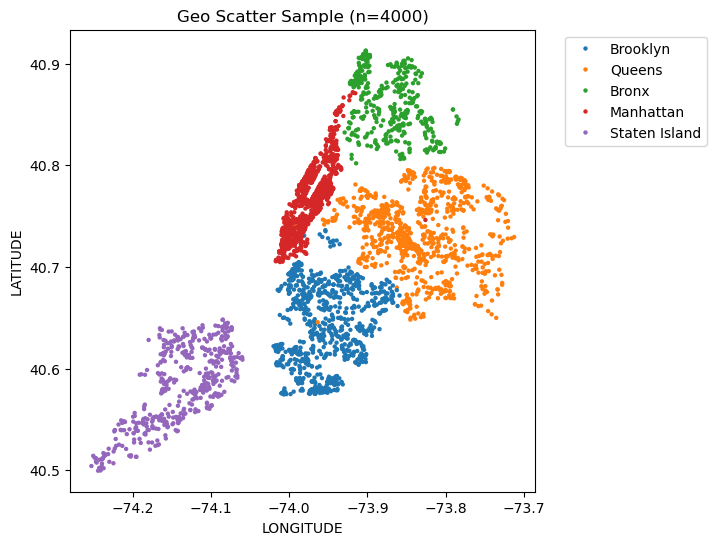

In [70]:
# Geo Scatter Visualization (run after full pipeline)
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
if 'merged_df' in globals():
    if {'LATITUDE','LONGITUDE'}.issubset(merged_df.columns):
        sample_size = min(CONFIG.get('geo_sample_size', 4000), len(merged_df))
        plot_df = merged_df.sample(sample_size, random_state=CONFIG.get('random_seed',42)) if sample_size else merged_df.copy()
        plt.figure(figsize=(6,6))
        sns.scatterplot(data=plot_df, x='LONGITUDE', y='LATITUDE', hue='BOROUGH', s=10, linewidth=0)
        plt.title(f'Geo Scatter Sample (n={sample_size})')
        plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
        plt.show()
    else:
        print('LATITUDE/LONGITUDE columns not present.')
else:
    print('merged_df not defined; run earlier cells first.')

In [71]:
# Export cleaned DataFrame (robust: create output dir if needed)
output_path = CONFIG['paths'].get('output_csv', 'output/cleaned_house_dataset.csv')
output_dir = os.path.dirname(output_path)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
merged_df.to_csv(output_path, index=False)
print(f"Cleaned data exported to: {output_path}")

Cleaned data exported to: output/cleaned_house_dataset.csv


In [27]:
merged_df[['TYPE']].value_counts()

TYPE 
house    2451
condo    2053
Name: count, dtype: int64

In [28]:
import pandas as pd
pd.set_option('display.max_colwidth', None)  # Show full address lists

# Get all unique ZIPCODEs
unique_zipcodes = merged_df['ZIPCODE'].dropna().unique()
for zipcode in unique_zipcodes:
    addresses = merged_df[merged_df['ZIPCODE'] == zipcode]['ADDRESS'].tolist()
    print(f"ZIPCODE: {zipcode}  (Total addresses: {len(addresses)})")
    for address in addresses:
        print(f"  - {address}")
    print("\n" + "-"*40 + "\n")

pd.reset_option('display.max_colwidth')

ZIPCODE: 10022  (Total addresses: 69)
  - Regis Residence, 2 E 55th Street #803, New York, Ny 10022
  - 2 E 55th Street, New York, Ny 10022
  - 246 E 58th Street, New York, Ny 10022
  - 444 E 57th Street #2D, New York, Ny 10022
  - 2 Sutton Place S, New York, Ny 10022
  - 231-235 E 55th Street # 45a, New York, Ny 10022
  - 303 E 57th Street #39A, New York, Ny 10022
  - 411 E 53rd Street #4J, New York, Ny 10022
  - 465 Park Avenue Apt 34e, New York, Ny 10022
  - 410 E 57th Street #8B, New York, Ny 10022
  - 6 Sutton Square, New York, Ny 10022
  - 303 E 57th Street #19B, New York, Ny 10022
  - 411 E 57th Street #16B, New York, Ny 10022
  - 420 E 51st Street Apartment 10e, New York, Ny 10022
  - 440 E 56th Street #4B, New York, Ny 10022
  - 240 E 55th Street #8E, New York, Ny 10022
  - 455 E 51st Street #4A, New York, Ny 10022
  - 401 E 60th Street #17A, New York, Ny 10022
  - 455 E 51st Street #4F, New York, Ny 10022
  - 315 E 51st Street, New York, Ny 10022
  - 321 E 54th Street #3C, Ne